# topologiq + tqec, end to end: teleportation_n3

## 1. The logical circuit (QASM)

In [1]:
import pathlib, sys
HERE = pathlib.Path.cwd()
sys.path.insert(0, str(HERE / "tools"))
from stage1_qasm import prepare_qasm
from saved import print_saved

NAME = "teleportation_n3"
original, gadget_qasm, meta = prepare_qasm(HERE, NAME)
print(original)
print(gadget_qasm)
print_saved(HERE)

// Teleportation using 3 qubits.
// Description: Based on the example given by S. Fedortchenko (https://arxiv.org/pdf/1607.02398.pdf) 

OPENQASM 2.0;
include "qelib1.inc";

qreg q[3];
creg c[3];

h q[0];
t q[0];
h q[0];
h q[2];
s q[0];
cx q[2],q[1];
cx q[0],q[1];
h q[0];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];

OPENQASM 2.0;
include "qelib1.inc";
qreg q[5];
h q[0];
cx q[0],q[3];
h q[0];
h q[2];
cx q[0],q[4];
cx q[2],q[1];
cx q[0],q[1];
h q[0];

saved:
  data/1_teleportation_n3.qasm             QASMBench original
  data/1_teleportation_n3_gadgets.qasm     what topologiq receives (T and S as gadgets)
  data/1_teleportation_n3_gadget_map.json  which magic wire belongs to which gate


## 2. topologiq output


=> Ingesting PyZX graph.
=> Building BlockGraph.
=> SUCCESS! Habemus BlockGraph. 
  - Volume: 12. 
  - Duration: 0.04s.
BLOCKGRAPH 0.1.0;

METADATA: attr_name; value;
source; topologiq;
circuit_name; 2_teleportation_n3_topologiq;

CUBES: index;x;y;z;kind;label;
0;0;0;0;OOO;in_0;
1;3;2;3;OOO;in_1;
2;2;3;5;OOO;in_2;
3;1;0;3;OOO;in_3;
4;2;1;1;OOO;in_4;
5;0;0;1;ZXX;;
6;0;0;3;ZXZ;;
7;0;0;2;ZXX;;
8;0;1;2;XXZ;;
9;2;2;5;ZXX;;
10;2;1;2;ZXZ;;
11;1;1;2;XXZ;;
12;2;2;3;ZXZ;;
13;2;2;4;ZXX;;
14;2;2;2;ZXZ;;
15;1;2;2;XXZ;;
16;1;3;2;ZXX;;
17;1;3;3;OOO;out_0;
18;3;2;2;OOO;out_1;
19;2;3;4;OOO;out_2;
20;0;0;4;OOO;out_3;
21;2;1;3;OOO;out_4;

PIPES: src;tgt;kind;
0;5;XZOH;
1;12;OXZ;
2;9;ZOXH;
3;6;OXZ;
4;10;ZXO;
5;7;ZXO;
6;7;ZXO;
6;20;ZXO;
7;8;ZOXH;
8;11;OXZ;
9;13;ZXO;
10;11;OXZ;
10;21;ZXO;
11;15;XOZ;
12;13;ZXO;
12;14;ZXO;
13;19;ZOX;
14;15;OXZ;
14;18;OXZ;
15;16;XOZH;
16;17;ZXO;



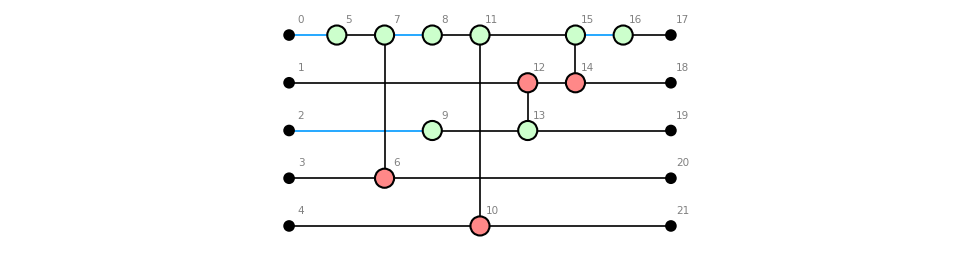

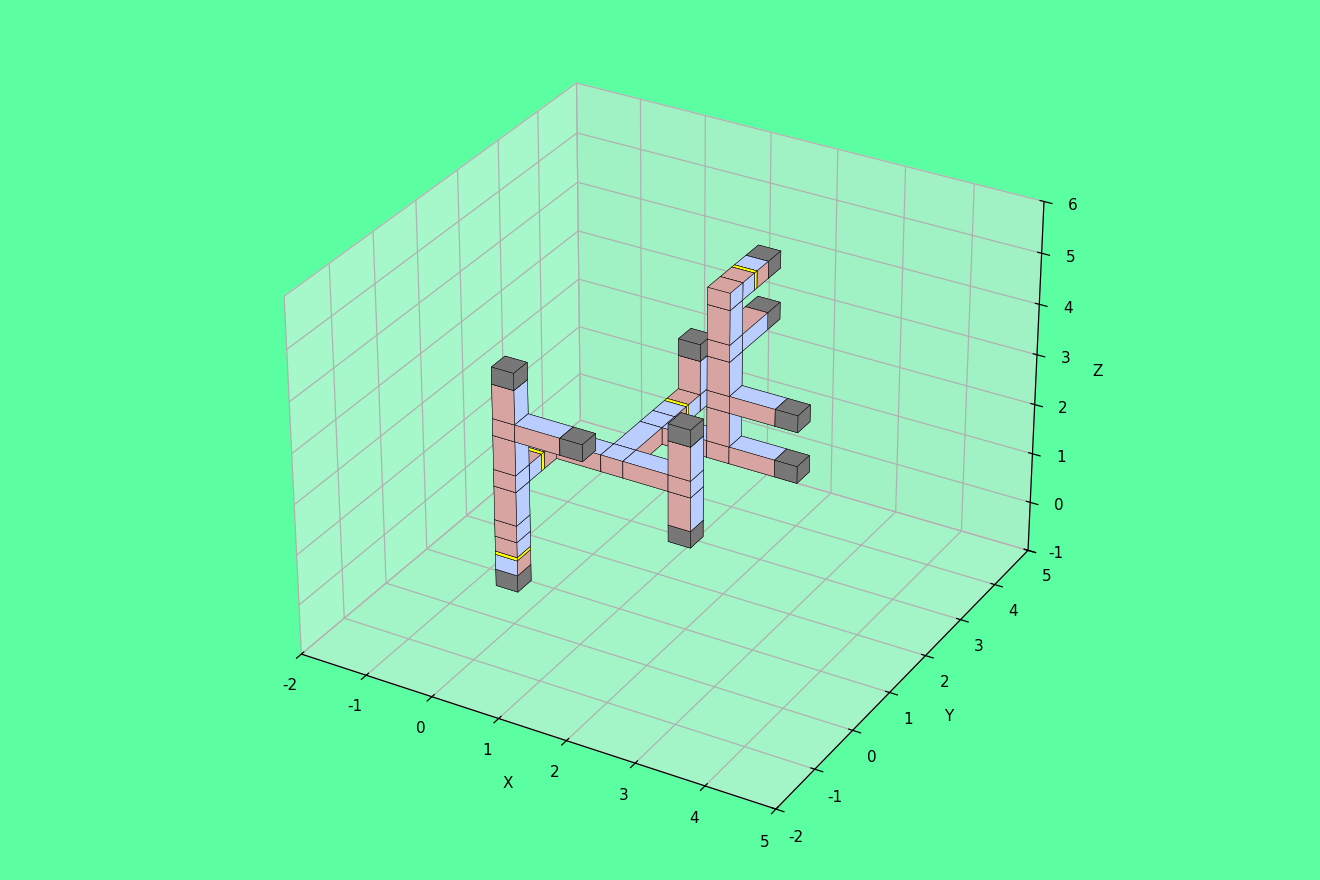

saved:
  data/2_teleportation_n3_topologiq.bgraph       topologiq's block graph (its native format)
  data/2_teleportation_n3_topologiq_console.txt  topologiq's console output
  data/2_teleportation_n3_topologiq_run.json     run statistics; same_as_recorded = equals the paper's run
  (ZX diagram: shown inline above, embedded in this notebook)
  (topologiq 3D view: shown inline above, embedded in this notebook)


In [2]:
from stage2_topologiq import run_topologiq, zx_diagram, topologiq_view

bgraph_text, console, mgr, stats = run_topologiq(HERE, NAME)
print(console)
print(bgraph_text)
zx_diagram(mgr)
topologiq_view(mgr)
print_saved(HERE)

## 3. TQEC block graph

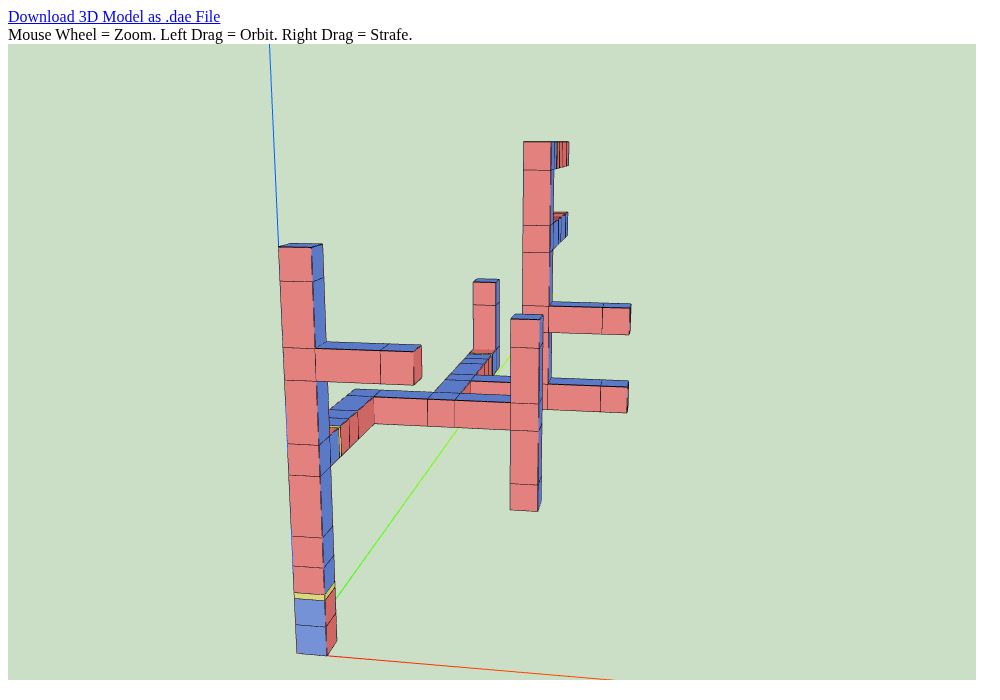

saved:
  blockgraph/teleportation_n3_open_port.dae     3D model, ports open (loads into tqec / SketchUp)
  blockgraph/teleportation_n3_open_port.html    rotatable viewer, ports open
  blockgraph/teleportation_n3_closed_port.dae   3D model, ports filled -- the compiled graph
  blockgraph/teleportation_n3_closed_port.html  rotatable viewer, ports filled
  blockgraph/tqec_validation.txt                closed graph reloaded, compiled and sampled at p=0 by tqec
  data/3_teleportation_n3_bridge.json           shim stats, equivalence result, port fill
  (closed-graph snapshot: shown inline above, embedded in this notebook)


In [3]:
from stage3_blockgraph import build_closed_graph, export_blockgraphs, show_closed_graph

g_open, g_closed, fill, surfaces = build_closed_graph(HERE, NAME, original, meta)
export_blockgraphs(HERE, NAME, g_open, g_closed)
show_closed_graph(HERE, NAME)
print_saved(HERE)

## 4. LER

sampling 15 LER point(s) with 8 worker processes ...


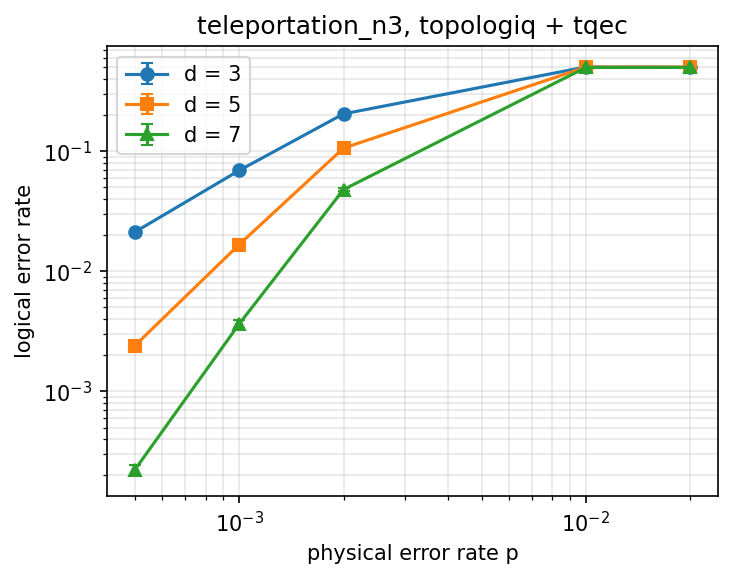

saved:
  stim_circuit/d3/4_teleportation_n3_clean.stim         d=3 circuit, noiseless
  stim_circuit/d3/4_teleportation_n3_noisy_p0.001.stim  d=3 circuit with p=0.001 noise
  data/4_teleportation_n3_compile_d3.json               d=3 compile report (convention, p=0 check, Table 2 sha check)
  stim_circuit/d5/4_teleportation_n3_clean.stim         d=5 circuit, noiseless
  stim_circuit/d5/4_teleportation_n3_noisy_p0.001.stim  d=5 circuit with p=0.001 noise
  data/4_teleportation_n3_compile_d5.json               d=5 compile report (convention, p=0 check, Table 2 sha check)
  stim_circuit/d7/4_teleportation_n3_clean.stim         d=7 circuit, noiseless
  stim_circuit/d7/4_teleportation_n3_noisy_p0.001.stim  d=7 circuit with p=0.001 noise
  data/4_teleportation_n3_compile_d7.json               d=7 compile report (convention, p=0 check, Table 2 sha check)
  data/4_teleportation_n3_ler_points.json               LER points (sampled by this run); delete the file to resample
  (LER plot: shown inli

In [4]:
from stage4_ler import compile_distances, ler_curve

circuits = compile_distances(HERE, NAME, meta)
points = ler_curve(HERE, NAME, circuits, workers=8)
print_saved(HERE)